# Extraction of CKM Angle $\gamma$ from $B \to DK$ Decays
## Symmetric Square Dalitz Plot Pipeline

This notebook extracts $\gamma$, $\delta_B$, and $r_B$ from $B^\pm \to [K_S\pi^+\pi^-]_D K^\pm$
decays using an unbinned maximum-likelihood fit in the **Square Dalitz Plot (SDP)**.

### Key conventions
- **Resonant pair**: $\pi^+\pi^-$ &nbsp;(`idx=(2,3,1)` with $s_{23}$ driving $m'$)
- **CP symmetry**: swapping $\pi^+\leftrightarrow\pi^-$ maps $(m', \theta') \to (m', 1-\theta')$
- **Flows trained** under the same $\pi^+\pi^-$ SDP convention (`flavor_SDP_sym_2e6/`,
  `even_SDP_sym_2e6/`, `odd_SDP_sym_2e6/`)

### Analysis steps
1. Load three normalising-flow ensembles (flavor $D^0$, CP-even, CP-odd)
2. Compute CP normalisation constants $\Gamma_\pm$
3. Generate pseudo-data $B^\pm$ samples at two benchmark points
4. Compute per-point interference terms $C$, $S$
5. Enforce the physicality constraint $|C| \le |J|$ (three methods)
6. Unbinned ML fit with iminuit â†’ $r_B$, $\delta_B$, $\gamma$
7. Ensemble fits for statistical uncertainties
8. Profile-likelihood scans for accurate error estimation

---
## 1. Physics Background

### Decay rates
For $B^\mp \to [K_S\pi^+\pi^-]_D K^\mp$ the Dalitz-plot rate is:

$$
\frac{d^2\Gamma^\mp}{ds_{12}\,ds_{13}} \propto
|A_D|^2 + r_B^2|\bar A_D|^2
\pm 2r_B\bigl[C\cos(\delta_B\mp\gamma) \mp S\sin(\delta_B\mp\gamma)\bigr]
$$

where $A_D(s_{12},s_{13})$ is the $D^0$ decay amplitude, $\bar A_D(s_{12},s_{13}) = A_D(s_{13},s_{12})$, and

$$
C(m',\theta') = \mathrm{Re}[A_D\bar A_D^*]/|A_D||\bar A_D|\cdot|A_D||\bar A_D|,
\qquad S = \sqrt{|A_D|^2|\bar A_D|^2 - C^2}\cdot\mathrm{sign}(\sin\Delta\phi)
$$

### Extracting $C$ from CP eigenstates
The CP eigenstates $A_{D_\pm} = (A_D \pm \bar A_D)/\sqrt2$ satisfy
$|A_{D_+}|^2 - |A_{D_-}|^2 = 2\,\mathrm{Re}(A_D\bar A_D^*) = 2C$, so:

$$
C = \frac{\Gamma_+ p_+(m',\theta') - \Gamma_- p_-(m',\theta')}{\Gamma_+ + \Gamma_-}
$$

where $p_\pm$ are the normalised SDP densities of $D_{CP}^\pm$ events and $\Gamma_\pm$ are the total CP-even/odd rates.

### Physicality constraint
Cauchyâ€“Schwarz requires $|C| \le |A_D||\bar A_D| \equiv \mathcal{J}$. Flow imperfections can violate this; we discuss remedies in Â§8.

---
## 2. Imports and Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import json, time
from pathlib import Path
from scipy.spatial import KDTree

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from iminuit import Minuit

from nflows.flows import Flow
from nflows.distributions import StandardNormal
from nflows.transforms import (
    CompositeTransform, InverseTransform,
    PiecewiseRationalQuadraticCouplingTransform,
    RandomPermutation,
    Sigmoid,
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

sns.set_style('ticks')
sns.set_context('paper', font_scale=1.4)
plt.rcParams['text.usetex'] = False  # set True if LaTeX is available


---
## 3. Helper Functions

### Coordinate conventions
We use the **$\pi^+\pi^-$ SDP** convention: `idx = (2, 3, 1)`

| quantity | expression |
|---|---|
| $s_{23} = m^2(\pi^+\pi^-)$ | $= M_D^2 + m_{K_S}^2 + 2m_\pi^2 - s_{12} - s_{13}$ |
| $m'$ | from $s_{23}$ via `MpfromM(s23, s12, 2, 3, 1)` |
| $\theta'$ | from $s_{12}$ via `TfromM(s23, s12, 2, 3, 1)` |
| $\pi^+\leftrightarrow\pi^-$ | $m'\to m'$, &nbsp;$\theta'\to 1-\theta'$ |

In [ ]:
from Amplitude import DKpp, BKpp, DalitzSample, AmpSample, SquareDalitzPlot2
from DKpp import DKppCorrelated

# Particle masses
mD, mKs, mpi = 1.86483, 0.497611, 0.13957018
sdp_obj = SquareDalitzPlot2(mD, mKs, mpi, mpi)
_sum_m2  = sdp_obj.mSq[0] + sdp_obj.mSq[1] + sdp_obj.mSq[2] + sdp_obj.mSq[3]

# Isobar amplitude model
dkpp = DKpp()


# ------------------------------------------------------------
def _finite_pos(x, eps=1e-14):
    """Replace non-finite values with eps; enforce x >= eps."""
    x = np.asarray(x, dtype=float)
    x = np.where(np.isfinite(x), x, 0.0)
    return np.maximum(x, eps)


# ------------------------------------------------------------
def dp_to_sdp(points_dp, sdp_obj=sdp_obj, idx=(2, 3, 1)):
    """
    Convert Dalitz-plot (s12, s13) -> SDP (m', theta').

    With idx=(2,3,1) the resonant pair is pi+pi-, so
        s_ij = s23 = M^2 + mK^2 + 2*mpi^2 - s12 - s13
        s_ik = s12
    """
    i, j, k = idx
    s12, s13 = points_dp[:, 0], points_dp[:, 1]
    s23 = _sum_m2 - s12 - s13
    mp = np.vectorize(lambda a, b: sdp_obj.MpfromM(a, b, i, j, k), otypes=[float])(s23, s12)
    tp = np.vectorize(lambda a, b: sdp_obj.TfromM(a, b, i, j, k),  otypes=[float])(s23, s12)
    return np.column_stack([mp, tp])


def sdp_to_dp(points_sdp, sdp_obj=sdp_obj, idx=(2, 3, 1)):
    """
    Convert SDP (m', theta') -> Dalitz-plot (s12, s13).

    M_from_MpT returns (s23, s12); we recover s13 = sum_m2 - s23 - s12.
    """
    i, j, k = idx
    out = np.empty_like(points_sdp, dtype=float)
    for n, (mp, tp) in enumerate(points_sdp):
        s23, s12 = sdp_obj.M_from_MpT(mp, tp, i, j, k)
        out[n, 0] = s12
        out[n, 1] = _sum_m2 - s23 - s12
    return out  # columns: [s12, s13]


def swap_to_other_pair_sdp(points_sdp):
    """
    Apply pi+ <-> pi- exchange in SDP coordinates.

    In the (2,3,1) convention, swapping s12 <-> s13 leaves s23 unchanged
    and flips the helicity angle, giving simply:
        m'     ->  m'          (unchanged)
        theta' ->  1 - theta'
    """
    out = np.array(points_sdp, copy=True, dtype=float)
    out[:, 1] = 1.0 - out[:, 1]
    return out


def sdp_uniform_mc(N, eps=1e-6):
    """Draw N points uniformly in [eps, 1-eps]^2 (SDP coordinates)."""
    return np.random.rand(N, 2) * (1 - 2*eps) + eps


# ------------------------------------------------------------
def mag_exact(points_sdp, dkpp_model=dkpp, sdp_obj=sdp_obj, idx=(2, 3, 1)):
    """
    Compute |A_D(s12,s13)| and 1/J at SDP grid points directly from
    the isobar model (no flow needed).

    Returns
    -------
    mag  : |A_D(s12, s13)|
    invJ : 1 / jacobian(s23, s12, 2, 3, 1)  (used in MC normalisation)
    """
    i, j, k = idx
    dp = sdp_to_dp(points_sdp, sdp_obj, idx)
    s12, s13 = dp[:, 0], dp[:, 1]
    s23 = _sum_m2 - s12 - s13
    J   = np.array([float(sdp_obj.jacobian(s23[n], s12[n], i, j, k))
                    for n in range(len(points_sdp))])
    A12 = dkpp_model.full(np.column_stack([s12, s13]))
    return np.abs(A12), _finite_pos(1.0 / J)


In [ ]:
def mag_AD_from_flow(points_sdp, flow, sdp_obj=sdp_obj, idx=(2, 3, 1), device=device):
    """
    Extract |A_D| at SDP points from a single normalising flow.

        p_SDP = |A_D|^2 / J_SDP  =>  mag = sqrt(p_SDP * J_SDP)

    Returns
    -------
    mag  : |A_D(s12, s13)|
    invJ : 1/J_SDP  (needed for correct MC normalisation in the likelihood)
    """
    i, j, k = idx
    pts_t = torch.from_numpy(np.ascontiguousarray(points_sdp)).float().to(device)
    flow.eval().to(device)
    with torch.no_grad():
        p_sdp = torch.exp(flow.log_prob(pts_t)).cpu().numpy()

    invJ = np.empty(len(points_sdp))
    for n, (mp, tp) in enumerate(points_sdp):
        sij, sik = sdp_obj.M_from_MpT(mp, tp, i, j, k)
        invJ[n] = 1.0 / float(sdp_obj.jacobian(sij, sik, i, j, k))
    invJ = _finite_pos(invJ)

    mag = np.sqrt(p_sdp / invJ)
    return mag, invJ


---
## 4. Dataset Class and Flow Architecture

The same architecture is used for all three flow types (flavor $D^0$, CP-even, CP-odd): a rational-quadratic neural spline flow on the unit square $[0,1]^2$.

In [ ]:
class DalitzDataset(Dataset):
    def __init__(self, data):
        self.data = (torch.FloatTensor(data)
                     if isinstance(data, np.ndarray)
                     else data.float())
    def __len__(self):          return len(self.data)
    def __getitem__(self, idx): return self.data[idx]


class MLP(nn.Module):
    """Conditioner MLP for coupling layers."""
    def __init__(self, in_features, out_features, hidden=64, layers=2, output_scale=0.30):
        super().__init__()
        feats = [nn.Linear(in_features, hidden), nn.SiLU()]
        for _ in range(layers - 1):
            feats += [nn.Linear(hidden, hidden), nn.SiLU()]
        self.backbone = nn.Sequential(*feats)
        self.head = nn.Linear(hidden, out_features)
        nn.init.zeros_(self.head.weight)
        nn.init.zeros_(self.head.bias)
        self.output_scale = output_scale
    def forward(self, x, context=None):
        return self.head(self.backbone(x)) * self.output_scale


def create_flow(on_unit_box=True, num_flows=12, hidden_features=128,
                num_bins=24, device=None):
    """
    Create a rational-quadratic neural spline flow on [0,1]^2.
    Architecture matches the training notebooks exactly.
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    dim = 2
    transforms = []

    if on_unit_box:
        sigmoid = Sigmoid()
        # Move plain tensor attributes that .to() misses
        if hasattr(sigmoid, "temperature") and isinstance(sigmoid.temperature, torch.Tensor):
            sigmoid.temperature = sigmoid.temperature.to(device)
        if hasattr(sigmoid, "eps") and isinstance(sigmoid.eps, torch.Tensor):
            sigmoid.eps = sigmoid.eps.to(device)
        transforms.append(InverseTransform(sigmoid))

    masks = [torch.tensor([1, 0], dtype=torch.bool),
             torch.tensor([0, 1], dtype=torch.bool)]

    for i in range(num_flows):
        def _conditioner(in_f, out_f, _h=hidden_features):
            return MLP(in_f, out_f, hidden=_h, layers=2)

        transforms.append(
            PiecewiseRationalQuadraticCouplingTransform(
                mask=masks[i % 2],
                transform_net_create_fn=_conditioner,
                num_bins=num_bins,
                tails="linear",
                tail_bound=5.0,
                apply_unconditional_transform=False,
            )
        )
        transforms.append(RandomPermutation(features=dim))

    return Flow(
        transform=CompositeTransform(transforms),
        distribution=StandardNormal([dim]),
    )


---
## 5. Load Trained Flow Ensembles

Three ensembles of 25 flows each, all trained with `idx=(2,3,1)` (the $\pi^+\pi^-$ SDP convention):

| Ensemble | Directory | Amplitude |
|---|---|---|
| Flavor $D^0$ | `flavor_SDP_sym_2e6/` | $|A_D(s_{12},s_{13})|^2$ |
| CP-even | `even_SDP_sym_2e6/` | $|A_D + \bar A_D|^2/2$ |
| CP-odd  | `odd_SDP_sym_2e6/`  | $|A_D - \bar A_D|^2/2$ |

The ensemble average reduces statistical uncertainty from the finite training samples.

In [ ]:
def load_flow(path, num_flows=12, hidden_features=128, num_bins=24, device=device):
    """Load a single flow checkpoint."""
    f = create_flow(num_flows=num_flows, hidden_features=hidden_features,
                    num_bins=num_bins, device=device)
    f.load_state_dict(torch.load(path, map_location=device))
    f.eval()
    return f


def load_ensemble(directory, n_models=25, num_flows=12,
                  hidden_features=128, num_bins=24, device=device):
    """
    Load up to n_models checkpoints from `directory/trial_seed*.pth`.
    Used by run_flow_ensemble_fits to iterate over independently trained flows.
    """
    ckpts = sorted(Path(directory).glob("trial_seed*.pth"))[:n_models]
    if not ckpts:
        raise FileNotFoundError(f"No checkpoints in {directory}")
    flows = [load_flow(ck, num_flows, hidden_features, num_bins, device)
             for ck in ckpts]
    print(f"  Loaded {len(flows)} flows from {directory}")
    return flows


print("Loading flows...")
# Load one representative flow per type for the main benchmark fits
flow_flavor = load_flow("flavor_SDP_sym_2e6/trial_seed1.pth")
flow_even   = load_flow("even_SDP_sym_2e6/trial_seed1.pth")
flow_odd    = load_flow("odd_SDP_sym_2e6/trial_seed1.pth")
print("Done.")


---
## 6. Compute CP Normalisation Constants $\Gamma_\pm$

$$
\Gamma_\pm = \int |A_D(s_{12},s_{13}) \pm A_D(s_{13},s_{12})|^2\,ds_{12}\,ds_{13}
$$

These constants appear in the formula for $C$:
$C = (\Gamma_+ p_+ - \Gamma_- p_-) / (\Gamma_+ + \Gamma_-)$

In [ ]:
def compute_Gamma_pm(dkpp_model=dkpp, sdp_obj=sdp_obj,
                     idx=(2, 3, 1), n_grid=800):
    """
    Integrate |A_D +/- Abar_D|^2 / J_SDP over the unit square.

    Uses a uniform (m', theta') grid; the Jacobian 1/J converts from
    SDP measure to the physical Dalitz-plot measure.
    """
    u = np.linspace(0, 1, n_grid)
    v = np.linspace(0, 1, n_grid)
    U, V = np.meshgrid(u, v, indexing='xy')
    pts = np.column_stack([U.ravel(), V.ravel()])

    dp   = sdp_to_dp(pts, sdp_obj, idx)
    s12, s13 = dp[:, 0], dp[:, 1]
    A12  = dkpp_model.full(np.column_stack([s12, s13]))
    A13s = dkpp_model.full(np.column_stack([s13, s12]))

    I_plus  = np.abs(A12 + A13s)**2
    I_minus = np.abs(A12 - A13s)**2

    # Jacobian for measure conversion
    i, j, k = idx
    s23 = _sum_m2 - s12 - s13
    J = np.array([float(sdp_obj.jacobian(s23[n], s12[n], i, j, k))
                  for n in range(len(pts))])
    invJ = _finite_pos(1.0 / J)

    dA = (1.0 / (n_grid - 1))**2
    Gp = np.sum(I_plus  * invJ) * dA
    Gm = np.sum(I_minus * invJ) * dA
    return Gp, Gm


print('Computing Gamma_+/-...')
Gamma_plus, Gamma_minus = compute_Gamma_pm()
print(f'  Gamma_+ = {Gamma_plus:.4f}')
print(f'  Gamma_- = {Gamma_minus:.4f}')


---
## 7. $B^\pm$ Sample Generation

Two benchmark physics points:

| Benchmark | $r_B$ | $\delta_B$ | $\gamma$ |
|---|---|---|---|
| A | 0.1 | 130Â° | 70Â° |
| B | 0.5 | 130Â° | 70Â° |

For each charge we generate `N_exp` experimental events (from `BKpp`) and `N_mc` Monte Carlo events drawn **uniformly in $(m',\theta')$** (used to numerically normalise the likelihood).

In [ ]:
def generate_BpBm_samples(
    rB, deltaB, gamma,
    N_exp, N_mc,
    sdp_obj=sdp_obj, idx=(2, 3, 1),
):
    """
    Generate B+/B- pseudo-data and uniform SDP Monte Carlo.

    Parameters
    ----------
    rB, deltaB, gamma : float
        True physics parameters (deltaB, gamma in radians).
    N_exp : int
        Experimental events per charge.
    N_mc : int
        Uniform SDP Monte Carlo events per charge (for normalisation).

    Returns
    -------
    dict with keys: dataM_sdp, dataP_sdp, mcM_sdp, mcP_sdp
    """
    bM = BKpp(rB=rB, deltaB=deltaB, gamma=gamma, Bcharge=-1)
    bP = BKpp(rB=rB, deltaB=deltaB, gamma=gamma, Bcharge=+1)

    print('Generating B- data...')
    t0 = time.time()
    dataM_dp = AmpSample(bM).generate(N_exp, nbatch=20_000)
    print(f'  {len(dataM_dp):,} events in {time.time()-t0:.1f}s')

    print('Generating B+ data...')
    t0 = time.time()
    dataP_dp = AmpSample(bP).generate(N_exp, nbatch=20_000)
    print(f'  {len(dataP_dp):,} events in {time.time()-t0:.1f}s')

    dataM_sdp = dp_to_sdp(dataM_dp, sdp_obj, idx)
    dataP_sdp = dp_to_sdp(dataP_dp, sdp_obj, idx)

    mcM_sdp = sdp_uniform_mc(N_mc)
    mcP_sdp = sdp_uniform_mc(N_mc)

    return dict(dataM_sdp=dataM_sdp, dataP_sdp=dataP_sdp,
                mcM_sdp=mcM_sdp,     mcP_sdp=mcP_sdp)


---
## 8. Compute Interference Terms $C$ and $S$

For each SDP point $(m',\theta')$ we compute:

| Symbol | Meaning |
|---|---|
| `pF` | $|A_D(s_{12},s_{13})|^2$ â€” from flavor flow |
| `pFsw` | $|A_D(s_{13},s_{12})|^2$ â€” flavor flow at $(m', 1-\theta')$ |
| `abJ` | $|A_D|\cdot|\bar A_D|$ â€” Cauchyâ€“Schwarz bound on $|C|$ |
| `C` | $(\Gamma_+ p_+ - \Gamma_- p_-)/(\Gamma_+ + \Gamma_-)$ |
| `S` | $\mathrm{sign}(\sin\Delta\phi)\sqrt{\mathcal{J}^2 - C^2}$ |
| `J` | $1/J_{SDP}$ â€” Jacobian factor for MC normalisation |

The sign of $S$ is taken from the exact isobar-model phase difference $\Delta\phi = \arg A_D - \arg\bar A_D$ to avoid flow sign ambiguity.

In [ ]:
def compute_interference_terms(
    points_sdp,
    flow_flavor, flow_even, flow_odd,
    dkpp_model=dkpp, sdp_obj=sdp_obj,
    Gamma_plus=1.0, Gamma_minus=1.0,
    idx=(2, 3, 1), device=device,
):
    """
    Compute per-point interference quantities using a single flow per type.

    In the pi+pi- convention, Abar_D is obtained by evaluating the flavor
    flow at the swapped point (m', 1-theta').
    """
    # |A_D(s12,s13)| and Jacobian
    mag12, invJ = mag_AD_from_flow(points_sdp, flow_flavor, sdp_obj, idx, device)

    # |Abar_D| = flavor flow at (m', 1-theta')
    pts_swap = swap_to_other_pair_sdp(points_sdp)
    mag13, _ = mag_AD_from_flow(pts_swap, flow_flavor, sdp_obj, idx, device)

    mag12 = _finite_pos(mag12)
    mag13 = _finite_pos(mag13)
    pF    = mag12**2
    pFsw  = mag13**2
    abJ   = mag12 * mag13

    # C from CP-even and CP-odd flows
    p_even = _finite_pos(mag_AD_from_flow(points_sdp, flow_even, sdp_obj, idx, device)[0])**2
    p_odd  = _finite_pos(mag_AD_from_flow(points_sdp, flow_odd,  sdp_obj, idx, device)[0])**2
    C = (Gamma_plus * p_even - Gamma_minus * p_odd) / (Gamma_plus + Gamma_minus)

    # Sign of S from exact isobar phases
    dp   = sdp_to_dp(points_sdp, sdp_obj, idx)
    s12, s13 = dp[:, 0], dp[:, 1]
    A12  = dkpp_model.full(np.column_stack([s12, s13]))
    A13s = dkpp_model.full(np.column_stack([s13, s12]))
    dphi = (np.angle(A12) - np.angle(A13s) + np.pi) % (2*np.pi) - np.pi
    S = np.sign(np.sin(dphi)) * np.sqrt(np.maximum(abJ**2 - C**2, 0.0))

    C = np.where(np.isfinite(C), C, 0.0)
    S = np.where(np.isfinite(S), S, 0.0)

    return dict(
        pF   = _finite_pos(pF),
        pFsw = _finite_pos(pFsw),
        C    = C,
        S    = S,
        abJ  = abJ,
        J    = _finite_pos(invJ),
    )


In [ ]:
def compute_interference_exact(
    points_sdp,
    dkpp_model=dkpp, sdp_obj=sdp_obj,
    idx=(2, 3, 1),
):
    """
    Compute per-point interference quantities using the isobar model directly.

    This is the "ground truth" reference: no flow approximation, no C constraint
    needed (Cauchy-Schwarz is satisfied exactly by construction).

    In the pi+pi- convention, the CP-conjugate amplitude Abar_D(s12,s13)
    = A_D(s13,s12) is obtained by evaluating the isobar at the swapped
    Dalitz-plot point, which in SDP coordinates is simply (m', 1-theta').

    Returns the same dict structure as compute_interference_terms so that
    build_nll can be used unchanged.
    """
    dp   = sdp_to_dp(points_sdp, sdp_obj, idx)
    s12, s13 = dp[:, 0], dp[:, 1]

    # |A_D(s12, s13)| and Jacobian at the data/MC SDP points
    mag12, invJ = mag_exact(points_sdp, dkpp_model, sdp_obj, idx)

    # |A_D(s13, s12)| = |Abar_D| at the pi+<->pi- swapped SDP point
    pts_swap = swap_to_other_pair_sdp(points_sdp)   # (m', 1-theta')
    mag13, _ = mag_exact(pts_swap, dkpp_model, sdp_obj, idx)

    mag12 = _finite_pos(mag12)
    mag13 = _finite_pos(mag13)

    pF   = mag12**2       # |A_D(s12,s13)|^2
    pFsw = mag13**2       # |A_D(s13,s12)|^2 = |Abar_D|^2
    abJ  = mag12 * mag13  # Cauchy-Schwarz bound (satisfied exactly here)

    # C and S from the full complex amplitudes
    A12  = dkpp_model.full(np.column_stack([s12, s13]))
    A13s = dkpp_model.full(np.column_stack([s13, s12]))
    dphi = (np.angle(A12) - np.angle(A13s) + np.pi) % (2*np.pi) - np.pi

    C = abJ * np.cos(dphi)   # = Re(A_D * Abar_D*)
    S = abJ * np.sin(dphi)   # = Im(A_D * Abar_D*)

    C = np.where(np.isfinite(C), C, 0.0)
    S = np.where(np.isfinite(S), S, 0.0)

    return dict(
        pF   = _finite_pos(pF),
        pFsw = _finite_pos(pFsw),
        C    = C,
        S    = S,
        abJ  = abJ,
        J    = _finite_pos(invJ),
    )


def fit_gamma_exact(
    dataM_sdp, dataP_sdp, mcM_sdp, mcP_sdp,
    dkpp_model=dkpp, sdp_obj=sdp_obj,
    true_rB=None, true_deltaB=None, true_gamma=None,
    init_rB_scale=0.2, delta_offset=30.0, gamma_offset=30.0,
    idx=(2, 3, 1),
):
    """
    Gamma fit using exact isobar-model C and S (no flows, no constraint needed).

    Serves as a reference/upper-bound on fit quality: any flow-based result
    should agree with this in the limit of perfect flow training.

    Parameters are the same subset of fit_gamma that are relevant here.
    """
    print('Computing exact interference terms...')
    kwargs = dict(dkpp_model=dkpp_model, sdp_obj=sdp_obj, idx=idx)
    tM = compute_interference_exact(dataM_sdp, **kwargs)
    tP = compute_interference_exact(dataP_sdp, **kwargs)
    mM = compute_interference_exact(mcM_sdp,   **kwargs)
    mP = compute_interference_exact(mcP_sdp,   **kwargs)

    nll = build_nll(tM, tP, mM, mP)

    rB0    = (true_rB    or 0.1) * init_rB_scale
    delta0 = (true_deltaB or 130.0) + delta_offset
    gamma0 = (true_gamma  or  70.0) + gamma_offset

    m = Minuit(nll, rB=rB0, delta=delta0, gamma=gamma0)
    m.limits['rB']    = (0.0, 1.0)
    m.limits['delta'] = (0.0, 360.0)
    m.limits['gamma'] = (0.0, 360.0)
    m.errors['rB']    = 0.01
    m.errors['delta'] = 2.0
    m.errors['gamma'] = 2.0
    m.errordef = Minuit.LIKELIHOOD

    t0 = time.time()
    m.migrad(); m.hesse()
    print(f'Exact fit time: {time.time()-t0:.1f}s | valid: {m.valid}')
    print(f'  rB    = {m.values["rB"]:.4f} +/- {m.errors["rB"]:.4f}'
          f'  (true: {true_rB})')
    print(f'  delta = {m.values["delta"]:.2f} +/- {m.errors["delta"]:.2f} deg'
          f'  (true: {true_deltaB})')
    print(f'  gamma = {m.values["gamma"]:.2f} +/- {m.errors["gamma"]:.2f} deg'
          f'  (true: {true_gamma})')

    terms = dict(tM=tM, tP=tP, mM=mM, mP=mP)
    return m, terms


---
## 9. Enforcing the Physicality Constraint $|C| \le \mathcal{J}$

Flow imperfections can produce $|C| > |A_D||\bar A_D|$, which is kinematically forbidden (Cauchyâ€“Schwarz). We provide four remedies:

| Method | Strategy |
|---|---|
| **Hard cut** | Remove all violating points (biases normalisation if violations cluster) |
| **Clamp** | Clip $C$ to $[-\mathcal{J}, \mathcal{J}]$, recompute $S$ |
| **KNN smoothing** | Average $C$, $\mathcal{J}$ over $K$ nearest SDP neighbours until satisfied; discard if $K > K_{\max}$ |
| **Nearest valid point** | For each violating event, scan a local SDP grid and find the nearest point where the flows themselves predict a valid $C$; replace $C$, $\mathcal{J}$, $S$ with that prediction |

**KNN smoothing** uses only already-computed values.  **Nearest valid point** re-evaluates the flows at candidate SDP positions and is more faithful to the flow model but slower.

In [ ]:
# --- Method 1: Hard cut -------------------------------------------------
def apply_hard_cut(t):
    """
    Remove points where |C| > abJ.
    Simple but reduces effective statistics and biases the normalisation
    if violations cluster in specific kinematic regions.
    """
    mask = np.abs(t['C']) <= t['abJ']
    n_kept = mask.sum()
    n_tot  = len(mask)
    print(f'    Hard cut: {n_tot - n_kept} / {n_tot} removed '
          f'({100*(n_tot-n_kept)/n_tot:.1f}%)')
    return {key: val[mask] for key, val in t.items()}


# --- Method 2: Clamp ----------------------------------------------------
def apply_clamp(t):
    """
    Project C onto [-abJ, +abJ] then recompute S preserving its sign.
    All points are kept; constraint is enforced exactly.
    """
    t = {k: v.copy() for k, v in t.items()}
    n_viol = (np.abs(t['C']) > t['abJ']).sum()
    sign_S = np.sign(t['S'])
    t['C'] = np.clip(t['C'], -t['abJ'], t['abJ'])
    t['S'] = sign_S * np.sqrt(np.maximum(t['abJ']**2 - t['C']**2, 0.0))
    print(f'    Clamp: {n_viol} / {len(t["C"])} points clamped '
          f'({100*n_viol/len(t["C"]):.1f}%)')
    return t


# --- Method 3: KNN smoothing --------------------------------------------
def apply_knn_smoothing(t, sdp_points, K_init=5, K_max=200):
    """
    For each violating point, average C and abJ over its K nearest
    SDP-space neighbours until |C_avg| <= abJ_avg.
    K is doubled each round; points still violated at K_max are discarded.

    This is the recommended method: it uses local information to regularise
    the flow prediction while introducing minimal kinematic distortion.

    Parameters
    ----------
    t         : dict from compute_interference_terms
    sdp_points: (N,2) array of the SDP coordinates of these points
    K_init    : starting number of neighbours
    K_max     : give up and discard point if K exceeds this
    """
    C   = t['C'].copy()
    abJ = t['abJ'].copy()
    S   = t['S'].copy()

    violated = np.abs(C) > abJ
    n_viol   = violated.sum()
    if n_viol == 0:
        return t

    print(f'    KNN: {n_viol} / {len(C)} violations '
          f'({100*n_viol/len(C):.1f}%), smoothing...')

    tree     = KDTree(sdp_points)
    keep     = np.ones(len(C), dtype=bool)
    viol_idx = np.where(violated)[0]

    for pt in viol_idx:
        K = K_init
        found = False
        while K <= K_max:
            _, nbrs = tree.query(sdp_points[pt], k=K)
            c_s   = np.concatenate([[C[pt]],   C[nbrs]]).mean()
            abJ_s = np.concatenate([[abJ[pt]], abJ[nbrs]]).mean()
            if np.abs(c_s) <= abJ_s:
                C[pt]   = c_s
                abJ[pt] = abJ_s
                found = True
                break
            K *= 2
        if not found:
            keep[pt] = False

    # Recompute S at smoothed points
    smoothed = viol_idx[keep[viol_idx]]
    S[smoothed] = (np.sign(S[smoothed])
                   * np.sqrt(np.maximum(abJ[smoothed]**2 - C[smoothed]**2, 0.0)))

    n_disc = (~keep[viol_idx]).sum()
    if n_disc:
        print(f'    KNN: {n_disc} points discarded (K > {K_max})')

    t_out        = {key: val[keep].copy() for key, val in t.items()}
    t_out['C']   = C[keep]
    t_out['abJ'] = abJ[keep]
    t_out['S']   = S[keep]
    return t_out


# --- Method 4: Nearest valid point --------------------------------------
def apply_nearest_valid_point(
    t, sdp_points,
    flow_flavor, flow_even, flow_odd,
    dkpp_model=dkpp, sdp_obj=sdp_obj,
    Gamma_plus=1.0, Gamma_minus=1.0,
    idx=(2, 3, 1), device=device,
    search_radius=0.05, n_steps=15,
):
    """
    For each violating point, search a local grid of SDP positions and
    replace C, abJ, S with values from the nearest grid point at which
    the flows predict |C| <= abJ.

    Unlike KNN smoothing (which averages existing computed values),
    this method re-evaluates the three flow ensembles at candidate SDP
    positions, so it is more faithful to the flow model at the cost of
    additional forward passes.

    The kinematic quantities pF, pFsw, and J are kept from the original
    data event (only C, abJ, S are replaced).  If no valid candidate is
    found within `search_radius`, the point is clamped as a fallback.

    Parameters
    ----------
    t             : dict from compute_interference_terms
    sdp_points    : (N,2) SDP coordinates matching t
    search_radius : half-width of the local search box in [m', theta'] units
    n_steps       : grid resolution; n_steps^2 candidates per violating point
    """
    C   = t['C'].copy()
    abJ = t['abJ'].copy()
    S   = t['S'].copy()

    violated = np.abs(C) > abJ
    n_viol   = violated.sum()
    if n_viol == 0:
        return t

    print(f'    NearestValid: {n_viol} / {len(C)} violations '
          f'({100*n_viol/len(C):.1f}%), correcting...')

    viol_idx = np.where(violated)[0]
    n_fallback = 0

    # Build a single batch of all candidate points for all violating events
    offsets = np.linspace(-search_radius, search_radius, n_steps)
    dxy = np.array([[dx, dy] for dx in offsets for dy in offsets])  # (n_steps^2, 2)

    for pt in viol_idx:
        center = sdp_points[pt]                          # (2,)
        cands  = np.clip(center + dxy, 1e-6, 1 - 1e-6)  # (n_steps^2, 2)

        # Evaluate interference terms at all candidates (single batch call)
        tc = compute_interference_terms(
            cands,
            flow_flavor=flow_flavor,
            flow_even=flow_even,
            flow_odd=flow_odd,
            dkpp_model=dkpp_model,
            sdp_obj=sdp_obj,
            Gamma_plus=Gamma_plus,
            Gamma_minus=Gamma_minus,
            idx=idx,
            device=device,
        )

        valid_mask = np.abs(tc['C']) <= tc['abJ']
        if valid_mask.any():
            # Pick the valid candidate closest to the original SDP point
            dists = np.sum((cands[valid_mask] - center) ** 2, axis=1)
            best  = np.where(valid_mask)[0][np.argmin(dists)]
            C[pt]   = tc['C'][best]
            abJ[pt] = tc['abJ'][best]
            S[pt]   = tc['S'][best]
        else:
            # Fallback: clamp C to [-abJ, +abJ]
            abJ_orig = abJ[pt]
            C[pt]   = np.clip(C[pt], -abJ_orig, abJ_orig)
            S[pt]   = np.sign(S[pt]) * np.sqrt(max(abJ_orig**2 - C[pt]**2, 0.0))
            n_fallback += 1

    if n_fallback:
        print(f'    NearestValid: {n_fallback} points clamped (no valid candidate found)')

    t_out        = {key: val.copy() for key, val in t.items()}
    t_out['C']   = C
    t_out['abJ'] = abJ
    t_out['S']   = S
    return t_out


# --- Convenience wrapper ------------------------------------------------
def constrain_C(t, sdp_points, method='knn', K_init=5, K_max=200,
                flow_flavor=None, flow_even=None, flow_odd=None,
                dkpp_model=dkpp, sdp_obj=sdp_obj,
                Gamma_plus=1.0, Gamma_minus=1.0,
                idx=(2, 3, 1), device=device,
                search_radius=0.05, n_steps=15):
    """
    Apply chosen constraint method.

    method : 'hard_cut' | 'clamp' | 'knn' | 'nearest_valid'

    For 'nearest_valid', the three flow ensembles must be provided via
    flows_flavor, flows_even, flows_odd.
    """
    if method == 'hard_cut':
        return apply_hard_cut(t)
    if method == 'clamp':
        return apply_clamp(t)
    if method == 'knn':
        return apply_knn_smoothing(t, sdp_points, K_init, K_max)
    if method == 'nearest_valid':
        assert flow_flavor is not None, \
            "nearest_valid requires flow_flavor, flow_even, flow_odd"
        return apply_nearest_valid_point(
            t, sdp_points,
            flow_flavor=flow_flavor, flow_even=flow_even, flow_odd=flow_odd,
            dkpp_model=dkpp_model, sdp_obj=sdp_obj,
            Gamma_plus=Gamma_plus, Gamma_minus=Gamma_minus,
            idx=idx, device=device,
            search_radius=search_radius, n_steps=n_steps,
        )
    raise ValueError(f'Unknown method: {method!r}. '
                     f'Choose from: hard_cut, clamp, knn, nearest_valid')

---
## 10. Unbinned Maximum-Likelihood Fit

### Likelihood
The extended NLL for $B^-$ and $B^+$ data is:

$$
-\ln\mathcal{L} =
-\sum_{i\in B^-}\ln p^-_i
+N_{B^-}\ln\overline{p^-_{\rm MC}}
-\sum_{j\in B^+}\ln p^+_j
+N_{B^+}\ln\overline{p^+_{\rm MC}}
$$

where
$$
p^-(m',\theta') = p_{\rm Fsw} + r_B^2 p_F + 2r_B[C\cos(\delta_B-\gamma)-S\sin(\delta_B-\gamma)]
$$
$$
p^+(m',\theta') = p_F + r_B^2 p_{\rm Fsw} + 2r_B[C\cos(\delta_B+\gamma)+S\sin(\delta_B+\gamma)]
$$

The MC average $\overline{p_{\rm MC}}$ is over uniform SDP points, each weighted by $1/J_{SDP}$ to convert from SDP measure to DP measure.

In [ ]:
def build_nll(tM, tP, mM, mP, eps=1e-14):
    """
    Build the NLL function from pre-computed interference term dicts.

    Returns a callable nll(rB, delta, gamma) where angles are in degrees.
    """
    N_expM = len(tM["C"])
    N_expP = len(tP["C"])

    def nll(rB, delta, gamma):
        thM = np.radians(delta - gamma)
        thP = np.radians(delta + gamma)

        pBm = (tM["pFsw"] + rB**2 * tM["pF"]
               + 2*rB*(np.cos(thM)*tM["C"] - np.sin(thM)*tM["S"]))
        pBp = (tP["pF"]   + rB**2 * tP["pFsw"]
               + 2*rB*(np.cos(thP)*tP["C"] + np.sin(thP)*tP["S"]))

        pBm = _finite_pos(pBm, eps)
        pBp = _finite_pos(pBp, eps)

        norm_m = _finite_pos(
            mM["J"] * (mM["pFsw"] + rB**2 * mM["pF"]
                       + 2*rB*(np.cos(thM)*mM["C"] - np.sin(thM)*mM["S"])), eps).mean()
        norm_p = _finite_pos(
            mP["J"] * (mP["pF"]   + rB**2 * mP["pFsw"]
                       + 2*rB*(np.cos(thP)*mP["C"] + np.sin(thP)*mP["S"])), eps).mean()

        return (- np.log(pBm).sum() + N_expM * np.log(norm_m)
                - np.log(pBp).sum() + N_expP * np.log(norm_p))

    return nll


def fit_gamma(
    dataM_sdp, dataP_sdp, mcM_sdp, mcP_sdp,
    flow_flavor=None, flow_even=None, flow_odd=None,
    dkpp_model=dkpp, sdp_obj=sdp_obj,
    Gamma_plus=None, Gamma_minus=None,
    true_rB=None, true_deltaB=None, true_gamma=None,
    constraint="knn", K_init=5, K_max=200,
    search_radius=0.05, n_steps=15,
    init_rB_scale=0.2, delta_offset=30.0, gamma_offset=30.0,
    device=device, idx=(2, 3, 1),
    precomputed=None,
):
    """
    Full gamma extraction fit using a single flow per type.

    Parameters
    ----------
    flow_flavor/even/odd : single Flow objects (not lists).
                           Pass None only when using precomputed.
    precomputed : dict with tM, tP, mM, mP to skip recomputation.
    """
    if precomputed is None:
        assert flow_flavor is not None, "Provide flow_flavor/even/odd or precomputed"
        Gp = Gamma_plus  if Gamma_plus  is not None else 1.0
        Gm = Gamma_minus if Gamma_minus is not None else 1.0

        print("Computing interference terms...")
        kwargs = dict(flow_flavor=flow_flavor, flow_even=flow_even,
                      flow_odd=flow_odd, dkpp_model=dkpp_model,
                      sdp_obj=sdp_obj, Gamma_plus=Gp, Gamma_minus=Gm,
                      idx=idx, device=device)
        tM = compute_interference_terms(dataM_sdp, **kwargs)
        tP = compute_interference_terms(dataP_sdp, **kwargs)
        mM = compute_interference_terms(mcM_sdp,   **kwargs)
        mP = compute_interference_terms(mcP_sdp,   **kwargs)
    else:
        tM, tP, mM, mP = (precomputed[k] for k in ("tM", "tP", "mM", "mP"))

    nv_kwargs = dict(
        flow_flavor=flow_flavor, flow_even=flow_even, flow_odd=flow_odd,
        dkpp_model=dkpp_model, sdp_obj=sdp_obj,
        Gamma_plus=Gamma_plus or 1.0, Gamma_minus=Gamma_minus or 1.0,
        idx=idx, device=device,
        search_radius=search_radius, n_steps=n_steps,
    )

    print(f"Applying constraint: {constraint}")
    tM = constrain_C(tM, dataM_sdp, method=constraint, K_init=K_init, K_max=K_max, **nv_kwargs)
    tP = constrain_C(tP, dataP_sdp, method=constraint, K_init=K_init, K_max=K_max, **nv_kwargs)
    mM = constrain_C(mM, mcM_sdp,   method=constraint, K_init=K_init, K_max=K_max, **nv_kwargs)
    mP = constrain_C(mP, mcP_sdp,   method=constraint, K_init=K_init, K_max=K_max, **nv_kwargs)

    nll = build_nll(tM, tP, mM, mP)

    rB0    = (true_rB    or 0.1) * init_rB_scale
    delta0 = (true_deltaB or 130.0) + delta_offset
    gamma0 = (true_gamma  or  70.0) + gamma_offset

    m = Minuit(nll, rB=rB0, delta=delta0, gamma=gamma0)
    m.limits["rB"]    = (0.0, 1.0)
    m.limits["delta"] = (0.0, 360.0)
    m.limits["gamma"] = (0.0, 360.0)
    m.errors["rB"]    = 0.01
    m.errors["delta"] = 2.0
    m.errors["gamma"] = 2.0
    m.errordef = Minuit.LIKELIHOOD

    t0 = time.time()
    m.migrad(); m.hesse()
    print(f"Fit time: {time.time()-t0:.1f}s | valid: {m.valid}")
    print(f"  rB    = {m.values['rB']:.4f} +/- {m.errors['rB']:.4f}  (true: {true_rB})")
    print(f"  delta = {m.values['delta']:.2f} +/- {m.errors['delta']:.2f} deg  (true: {true_deltaB})")
    print(f"  gamma = {m.values['gamma']:.2f} +/- {m.errors['gamma']:.2f} deg  (true: {true_gamma})")

    return m, dict(tM=tM, tP=tP, mM=mM, mP=mP)


---
## 11. Benchmark Fits

### Benchmark A: $r_B = 0.1$, $\delta_B = 130Â°$, $\gamma = 70Â°$

At small $r_B$, the interference term is suppressed and the fit is statistically harder. We use 50k events per charge and 500k MC events.

In [36]:
# True physics parameters (Benchmark A)
true_rB_A    = 0.1
true_deltaB  = 130.0  # degrees
true_gamma   =  70.0  # degrees

# Generate pseudo-data
np.random.seed(42)
samples_A = generate_BpBm_samples(
    rB      = true_rB_A,
    deltaB  = np.radians(true_deltaB),
    gamma   = np.radians(true_gamma),
    N_exp   = 100_000,
    N_mc    = 1_000_000,
)
np.savez('BpBm_samples_rB0.1.npz', **samples_A)
print('Saved BpBm_samples_rB0.1.npz')


Generating B- data...
  100,000 events in 16.8s
Generating B+ data...
  100,000 events in 15.2s
Saved BpBm_samples_rB0.1.npz


In [ ]:
# Fit Benchmark A
m_A, terms_A = fit_gamma(
    dataM_sdp   = samples_A['dataM_sdp'],
    dataP_sdp   = samples_A['dataP_sdp'],
    mcM_sdp     = samples_A['mcM_sdp'],
    mcP_sdp     = samples_A['mcP_sdp'],
    flow_flavor = flow_flavor,
    flow_even   = flow_even,
    flow_odd    = flow_odd,
    Gamma_plus  = Gamma_plus,
    Gamma_minus = Gamma_minus,
    true_rB     = true_rB_A,
    true_deltaB = true_deltaB,
    true_gamma  = true_gamma,
    constraint  = 'knn',
    K_init=5, K_max=200,
)

### Benchmark B: $r_B = 0.5$, $\delta_B = 130Â°$, $\gamma = 70Â°$

At large $r_B$ the interference is strong; fit convergence is typically easier and uncertainties are smaller.

In [ ]:
# True physics parameters (Benchmark B)
true_rB_B = 0.5

np.random.seed(43)
samples_B = generate_BpBm_samples(
    rB      = true_rB_B,
    deltaB  = np.radians(true_deltaB),
    gamma   = np.radians(true_gamma),
    N_exp   = 50_000,
    N_mc    = 500_000,
)
np.savez('BpBm_samples_rB0.5.npz', **samples_B)
print('Saved BpBm_samples_rB0.5.npz')


In [ ]:
# Fit Benchmark B
m_B, terms_B = fit_gamma(
    dataM_sdp   = samples_B['dataM_sdp'],
    dataP_sdp   = samples_B['dataP_sdp'],
    mcM_sdp     = samples_B['mcM_sdp'],
    mcP_sdp     = samples_B['mcP_sdp'],
    flow_flavor = flow_flavor,
    flow_even   = flow_even,
    flow_odd    = flow_odd,
    Gamma_plus  = Gamma_plus,
    Gamma_minus = Gamma_minus,
    true_rB     = true_rB_B,
    true_deltaB = true_deltaB,
    true_gamma  = true_gamma,
    constraint  = 'knn',
    K_init=5, K_max=200,
)

### Benchmark Fits — Exact Isobar Model (Reference)

In [37]:
# Exact fits using isobar model directly (no flows) — reference comparison
print('=== Exact fit — Benchmark A (rB=0.1) ===')
m_A_exact, terms_A_exact = fit_gamma_exact(
    dataM_sdp   = samples_A['dataM_sdp'],
    dataP_sdp   = samples_A['dataP_sdp'],
    mcM_sdp     = samples_A['mcM_sdp'],
    mcP_sdp     = samples_A['mcP_sdp'],
    true_rB     = true_rB_A,
    true_deltaB = true_deltaB,
    true_gamma  = true_gamma,
)

print()
print('=== Exact fit — Benchmark B (rB=0.5) ===')
m_B_exact, terms_B_exact = fit_gamma_exact(
    dataM_sdp   = samples_B['dataM_sdp'],
    dataP_sdp   = samples_B['dataP_sdp'],
    mcM_sdp     = samples_B['mcM_sdp'],
    mcP_sdp     = samples_B['mcP_sdp'],
    true_rB     = true_rB_B,
    true_deltaB = true_deltaB,
    true_gamma  = true_gamma,
)


=== Exact fit — Benchmark A (rB=0.1) ===
Computing exact interference terms...
Exact fit time: 2.9s | valid: True
  rB    = 0.1010 +/- 0.0017  (true: 0.1)
  delta = 129.40 +/- 1.10 deg  (true: 130.0)
  gamma = 69.34 +/- 1.10 deg  (true: 70.0)

=== Exact fit — Benchmark B (rB=0.5) ===
Computing exact interference terms...
Exact fit time: 1.4s | valid: True
  rB    = 0.5013 +/- 0.0026  (true: 0.5)
  delta = 129.75 +/- 0.51 deg  (true: 130.0)
  gamma = 69.99 +/- 0.51 deg  (true: 70.0)


---
## 12. Flow Ensemble Fits — Flow Model Uncertainty

Fix the B data; fit once per independently trained flow triplet.
The spread of fitted values across triplets measures the **flow model uncertainty** from finite training statistics.

$$
\sigma_{\rm total} = \sqrt{\sigma_{\rm fit}^2 + \sigma_{\rm flow}^2}
$$

$\sigma_{\rm fit}$: mean HESSE error (data uncertainty); $\sigma_{\rm flow}$: std across flow triplets.

In [ ]:
def run_flow_ensemble_fits(
    dataM_sdp, dataP_sdp, mcM_sdp, mcP_sdp,
    flavor_dir, even_dir, odd_dir,
    true_rB, true_deltaB, true_gamma,
    Gamma_plus=Gamma_plus, Gamma_minus=Gamma_minus,
    constraint="knn", K_init=5, K_max=200,
    n_max=None,
    num_flows=12, hidden_features=128, num_bins=24,
    device=device, idx=(2, 3, 1),
):
    """
    Fix B data; fit once per independently trained flow triplet.

    Each trial loads one checkpoint from each directory and fits on the
    same fixed B data.  The spread of results quantifies the flow model
    uncertainty from finite training statistics.
    """
    ckpts_f = sorted(Path(flavor_dir).glob("trial_seed*.pth"))
    ckpts_e = sorted(Path(even_dir).glob("trial_seed*.pth"))
    ckpts_o = sorted(Path(odd_dir).glob("trial_seed*.pth"))

    n_trials = min(len(ckpts_f), len(ckpts_e), len(ckpts_o))
    if n_max is not None:
        n_trials = min(n_trials, n_max)
    print(f"Running {n_trials} flow-triplet fits on fixed B data...")

    results = []
    for i in range(n_trials):
        print(f"\n--- Flow triplet {i+1}/{n_trials}: "
              f"{ckpts_f[i].name} / {ckpts_e[i].name} / {ckpts_o[i].name} ---")
        fl = load_flow(ckpts_f[i], num_flows, hidden_features, num_bins, device)
        fe = load_flow(ckpts_e[i], num_flows, hidden_features, num_bins, device)
        fo = load_flow(ckpts_o[i], num_flows, hidden_features, num_bins, device)

        try:
            m_i, _ = fit_gamma(
                dataM_sdp=dataM_sdp, dataP_sdp=dataP_sdp,
                mcM_sdp=mcM_sdp,     mcP_sdp=mcP_sdp,
                flow_flavor=fl, flow_even=fe, flow_odd=fo,
                Gamma_plus=Gamma_plus, Gamma_minus=Gamma_minus,
                true_rB=true_rB, true_deltaB=true_deltaB, true_gamma=true_gamma,
                constraint=constraint, K_init=K_init, K_max=K_max,
                device=device, idx=idx,
            )
            results.append(dict(
                rB=m_i.values["rB"],       err_rB=m_i.errors["rB"],
                delta=m_i.values["delta"], err_delta=m_i.errors["delta"],
                gamma=m_i.values["gamma"], err_gamma=m_i.errors["gamma"],
                valid=m_i.valid,
            ))
        except Exception as e:
            print(f"  Fit failed: {e}")

    return results


def summarise_flow_ensemble(results, true_rB, true_deltaB, true_gamma):
    """Print mean, sigma_fit (mean HESSE), sigma_flow (std), sigma_total."""
    valid = [r for r in results if r["valid"]]
    print(f"Converged fits: {len(valid)} / {len(results)}")
    print(f"{'Parameter':<12} {'Mean':>10} {'sigma_fit':>12} {'sigma_flow':>12} {'sigma_total':>12} {'True':>10}")
    print("=" * 70)
    for param, truth in [("rB", true_rB), ("delta", true_deltaB), ("gamma", true_gamma)]:
        vals = np.array([r[param]          for r in valid])
        errs = np.array([r[f"err_{param}"] for r in valid])
        sf   = errs.mean()
        sl   = vals.std()
        st   = np.sqrt(sf**2 + sl**2)
        print(f"{param:<12} {vals.mean():>10.4f} {sf:>12.4f} {sl:>12.4f} {st:>12.4f} {truth:>10.4f}")


### Flow Ensemble — Benchmark A ($r_B = 0.1$)

In [ ]:
# ── Benchmark A: hard_cut vs clamp ─────────────────────────────────────────
_common_A = dict(
    dataM_sdp   = samples_A['dataM_sdp'],
    dataP_sdp   = samples_A['dataP_sdp'],
    mcM_sdp     = samples_A['mcM_sdp'],
    mcP_sdp     = samples_A['mcP_sdp'],
    flavor_dir  = 'flavor_SDP_sym_2e6',
    even_dir    = 'even_SDP_sym_2e6',
    odd_dir     = 'odd_SDP_sym_2e6',
    true_rB     = 0.1,
    true_deltaB = 130.0,
    true_gamma  =  70.0,
)

print('=== Benchmark A — hard_cut (violations discarded) ===')
flow_ens_A_cut = run_flow_ensemble_fits(**_common_A, constraint='hard_cut')
summarise_flow_ensemble(flow_ens_A_cut, 0.1, 130.0, 70.0)

print()
print('=== Benchmark A — clamp (violations projected onto boundary) ===')
flow_ens_A_clamp = run_flow_ensemble_fits(**_common_A, constraint='clamp')
summarise_flow_ensemble(flow_ens_A_clamp, 0.1, 130.0, 70.0)

# Keep a combined alias for the plotting cells
flow_ens_A = flow_ens_A_clamp   # default used downstream


In [ ]:

flow_ens_A_avg = run_flow_ensemble_fits(**_common_A, constraint='knn', K_init=2, K_max = 1000)
summarise_flow_ensemble(flow_ens_A_avg, 0.1, 130.0, 70.0)

Running 25 flow-triplet fits on fixed B data...

--- Flow triplet 1/25: trial_seed0.pth / trial_seed0.pth / trial_seed0.pth ---
Computing interference terms...
Applying constraint: knn
    KNN: 18324 / 100000 violations (18.3%), smoothing...
    KNN: 12517 points discarded (K > 200)
    KNN: 17357 / 100000 violations (17.4%), smoothing...
    KNN: 11549 points discarded (K > 200)
    KNN: 180815 / 1000000 violations (18.1%), smoothing...
    KNN: 134963 points discarded (K > 200)
    KNN: 180965 / 1000000 violations (18.1%), smoothing...
    KNN: 134543 points discarded (K > 200)
Fit time: 2.3s | valid: True
  rB    = 0.1047 +/- 0.0018  (true: 0.1)
  delta = 130.44 +/- 1.07 deg  (true: 130.0)
  gamma = 65.00 +/- 1.06 deg  (true: 70.0)

--- Flow triplet 2/25: trial_seed1.pth / trial_seed1.pth / trial_seed1.pth ---
Computing interference terms...
Applying constraint: knn
    KNN: 16958 / 100000 violations (17.0%), smoothing...
    KNN: 11007 points discarded (K > 200)
    KNN: 13685 / 10

In [69]:
flow_ens_A_avg = run_flow_ensemble_fits(**_common_A, constraint='knn', K_init=2, K_max = 1000)
summarise_flow_ensemble(flow_ens_A_avg, 0.1, 130.0, 70.0)

Running 25 flow-triplet fits on fixed B data...

--- Flow triplet 1/25: trial_seed0.pth / trial_seed0.pth / trial_seed0.pth ---
Computing interference terms...
Applying constraint: knn
    KNN: 18324 / 100000 violations (18.3%), smoothing...
    KNN: 9445 points discarded (K > 1000)
    KNN: 17357 / 100000 violations (17.4%), smoothing...
    KNN: 7708 points discarded (K > 1000)
    KNN: 180815 / 1000000 violations (18.1%), smoothing...
    KNN: 103656 points discarded (K > 1000)
    KNN: 180965 / 1000000 violations (18.1%), smoothing...
    KNN: 103733 points discarded (K > 1000)
Fit time: 2.6s | valid: True
  rB    = 0.1114 +/- 0.0017  (true: 0.1)
  delta = 129.13 +/- 1.04 deg  (true: 130.0)
  gamma = 65.44 +/- 1.04 deg  (true: 70.0)

--- Flow triplet 2/25: trial_seed1.pth / trial_seed1.pth / trial_seed1.pth ---
Computing interference terms...
Applying constraint: knn
    KNN: 16958 / 100000 violations (17.0%), smoothing...
    KNN: 5743 points discarded (K > 1000)
    KNN: 13685 / 

In [70]:
flow_ens_A_avg = run_flow_ensemble_fits(**_common_A, constraint='knn', K_init=2, K_max = 5000)
summarise_flow_ensemble(flow_ens_A_avg, 0.1, 130.0, 70.0)

Running 25 flow-triplet fits on fixed B data...

--- Flow triplet 1/25: trial_seed0.pth / trial_seed0.pth / trial_seed0.pth ---
Computing interference terms...
Applying constraint: knn
    KNN: 18324 / 100000 violations (18.3%), smoothing...
    KNN: 56 points discarded (K > 5000)
    KNN: 17357 / 100000 violations (17.4%), smoothing...
    KNN: 140 points discarded (K > 5000)
    KNN: 180815 / 1000000 violations (18.1%), smoothing...
    KNN: 37974 points discarded (K > 5000)
    KNN: 180965 / 1000000 violations (18.1%), smoothing...
    KNN: 38200 points discarded (K > 5000)
Fit time: 3.2s | valid: True
  rB    = 0.0997 +/- 0.0012  (true: 0.1)
  delta = 127.32 +/- 1.07 deg  (true: 130.0)
  gamma = 68.91 +/- 1.09 deg  (true: 70.0)

--- Flow triplet 2/25: trial_seed1.pth / trial_seed1.pth / trial_seed1.pth ---
Computing interference terms...
Applying constraint: knn
    KNN: 16958 / 100000 violations (17.0%), smoothing...
    KNN: 13685 / 100000 violations (13.7%), smoothing...
    KNN

In [72]:
flow_ens_A_avg = run_flow_ensemble_fits(**_common_A, constraint='knn', K_init=2, K_max = 2000)
summarise_flow_ensemble(flow_ens_A_avg, 0.1, 130.0, 70.0)

Running 25 flow-triplet fits on fixed B data...

--- Flow triplet 1/25: trial_seed0.pth / trial_seed0.pth / trial_seed0.pth ---
Computing interference terms...


c:\Users\chinh\anaconda3\Lib\site-packages\nflows\transforms\coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


Applying constraint: knn
    KNN: 18324 / 100000 violations (18.3%), smoothing...
    KNN: 6009 points discarded (K > 2000)
    KNN: 17357 / 100000 violations (17.4%), smoothing...
    KNN: 4571 points discarded (K > 2000)
    KNN: 180815 / 1000000 violations (18.1%), smoothing...
    KNN: 81105 points discarded (K > 2000)
    KNN: 180965 / 1000000 violations (18.1%), smoothing...
    KNN: 81759 points discarded (K > 2000)
Fit time: 2.7s | valid: True
  rB    = 0.1084 +/- 0.0017  (true: 0.1)
  delta = 127.56 +/- 1.05 deg  (true: 130.0)
  gamma = 67.43 +/- 1.06 deg  (true: 70.0)

--- Flow triplet 2/25: trial_seed1.pth / trial_seed1.pth / trial_seed1.pth ---
Computing interference terms...
Applying constraint: knn
    KNN: 16958 / 100000 violations (17.0%), smoothing...
    KNN: 2790 points discarded (K > 2000)
    KNN: 13685 / 100000 violations (13.7%), smoothing...
    KNN: 1600 points discarded (K > 2000)
    KNN: 199060 / 1000000 violations (19.9%), smoothing...
    KNN: 105180 point

In [ ]:
# ── Benchmark B: hard_cut vs clamp ─────────────────────────────────────────
_common_B = dict(
    dataM_sdp   = samples_B['dataM_sdp'],
    dataP_sdp   = samples_B['dataP_sdp'],
    mcM_sdp     = samples_B['mcM_sdp'],
    mcP_sdp     = samples_B['mcP_sdp'],
    flavor_dir  = 'flavor_SDP_sym_2e6',
    even_dir    = 'even_SDP_sym_2e6',
    odd_dir     = 'odd_SDP_sym_2e6',
    true_rB     = 0.5,
    true_deltaB = 130.0,
    true_gamma  =  70.0,
)

flow_ens_B_avg = run_flow_ensemble_fits(**_common_B, constraint='knn', K_init=2, K_max = 2000)
summarise_flow_ensemble(flow_ens_B_avg, 0.5, 130.0, 70.0)


Running 25 flow-triplet fits on fixed B data...

--- Flow triplet 1/25: trial_seed0.pth / trial_seed0.pth / trial_seed0.pth ---
Computing interference terms...


c:\Users\chinh\anaconda3\Lib\site-packages\nflows\transforms\coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


Applying constraint: knn
    KNN: 8848 / 50000 violations (17.7%), smoothing...
    KNN: 507 points discarded (K > 2000)
    KNN: 9181 / 50000 violations (18.4%), smoothing...
    KNN: 545 points discarded (K > 2000)
    KNN: 90463 / 500000 violations (18.1%), smoothing...
    KNN: 29806 points discarded (K > 2000)
    KNN: 90203 / 500000 violations (18.0%), smoothing...
    KNN: 29749 points discarded (K > 2000)
Fit time: 1.9s | valid: True
  rB    = 0.5015 +/- 0.0026  (true: 0.5)
  delta = 131.01 +/- 0.27 deg  (true: 130.0)
  gamma = 71.54 +/- 0.28 deg  (true: 70.0)

--- Flow triplet 2/25: trial_seed1.pth / trial_seed1.pth / trial_seed1.pth ---
Computing interference terms...
Applying constraint: knn
    KNN: 8167 / 50000 violations (16.3%), smoothing...
    KNN: 89 points discarded (K > 2000)
    KNN: 7265 / 50000 violations (14.5%), smoothing...
    KNN: 207 points discarded (K > 2000)
    KNN: 99506 / 500000 violations (19.9%), smoothing...
    KNN: 41951 points discarded (K > 200

In [ ]:
flow_ens_B_avg_2 = run_flow_ensemble_fits(**_common_B, constraint='knn', K_init=2, K_max = 1500)
summarise_flow_ensemble(flow_ens_B_avg_2, 0.5, 130.0, 70.0)

flow_ens_B_avg_3 = run_flow_ensemble_fits(**_common_B, constraint='knn', K_init=2, K_max = 1000)
summarise_flow_ensemble(flow_ens_B_avg_3, 0.5, 130.0, 70.0)

flow_ens_B_avg_4 = run_flow_ensemble_fits(**_common_B, constraint='knn', K_init=2, K_max = 750)
summarise_flow_ensemble(flow_ens_B_avg_4, 0.5, 130.0, 70.0)

flow_ens_B_avg_5 = run_flow_ensemble_fits(**_common_B, constraint='knn', K_init=2, K_max = 500)
summarise_flow_ensemble(flow_ens_B_avg_5, 0.5, 130.0, 70.0)


Running 25 flow-triplet fits on fixed B data...

--- Flow triplet 1/25: trial_seed0.pth / trial_seed0.pth / trial_seed0.pth ---
Computing interference terms...


c:\Users\chinh\anaconda3\Lib\site-packages\nflows\transforms\coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


KeyboardInterrupt: 

### Flow Ensemble — Benchmark B ($r_B = 0.5$)

In [ ]:
# ── Benchmark B: hard_cut vs clamp ─────────────────────────────────────────
_common_B = dict(
    dataM_sdp   = samples_B['dataM_sdp'],
    dataP_sdp   = samples_B['dataP_sdp'],
    mcM_sdp     = samples_B['mcM_sdp'],
    mcP_sdp     = samples_B['mcP_sdp'],
    flavor_dir  = 'flavor_SDP_sym_2e6',
    even_dir    = 'even_SDP_sym_2e6',
    odd_dir     = 'odd_SDP_sym_2e6',
    true_rB     = 0.5,
    true_deltaB = 130.0,
    true_gamma  =  70.0,
)

flow_ens_B_avg = run_flow_ensemble_fits(**_common_B, constraint='knn', K_init=2, K_max = 2000)
summarise_flow_ensemble(flow_ens_B_avg, 0.5, 130.0, 70.0)


Running 25 flow-triplet fits on fixed B data...

--- Flow triplet 1/25: trial_seed0.pth / trial_seed0.pth / trial_seed0.pth ---
Computing interference terms...


c:\Users\chinh\anaconda3\Lib\site-packages\nflows\transforms\coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


Applying constraint: knn
    KNN: 8848 / 50000 violations (17.7%), smoothing...
    KNN: 507 points discarded (K > 2000)
    KNN: 9181 / 50000 violations (18.4%), smoothing...
    KNN: 545 points discarded (K > 2000)
    KNN: 90463 / 500000 violations (18.1%), smoothing...
    KNN: 29806 points discarded (K > 2000)
    KNN: 90203 / 500000 violations (18.0%), smoothing...
    KNN: 29749 points discarded (K > 2000)
Fit time: 1.9s | valid: True
  rB    = 0.5015 +/- 0.0026  (true: 0.5)
  delta = 131.01 +/- 0.27 deg  (true: 130.0)
  gamma = 71.54 +/- 0.28 deg  (true: 70.0)

--- Flow triplet 2/25: trial_seed1.pth / trial_seed1.pth / trial_seed1.pth ---
Computing interference terms...
Applying constraint: knn
    KNN: 8167 / 50000 violations (16.3%), smoothing...
    KNN: 89 points discarded (K > 2000)
    KNN: 7265 / 50000 violations (14.5%), smoothing...
    KNN: 207 points discarded (K > 2000)
    KNN: 99506 / 500000 violations (19.9%), smoothing...
    KNN: 41951 points discarded (K > 200

In [ ]:
# ── Benchmark B: hard_cut vs clamp ─────────────────────────────────────────
_common_B = dict(
    dataM_sdp   = samples_B['dataM_sdp'],
    dataP_sdp   = samples_B['dataP_sdp'],
    mcM_sdp     = samples_B['mcM_sdp'],
    mcP_sdp     = samples_B['mcP_sdp'],
    flavor_dir  = 'flavor_SDP_sym_2e6',
    even_dir    = 'even_SDP_sym_2e6',
    odd_dir     = 'odd_SDP_sym_2e6',
    true_rB     = 0.5,
    true_deltaB = 130.0,
    true_gamma  =  70.0,
)

print('=== Benchmark B — hard_cut (violations discarded) ===')
flow_ens_B_cut = run_flow_ensemble_fits(**_common_B, constraint='hard_cut')
summarise_flow_ensemble(flow_ens_B_cut, 0.5, 130.0, 70.0)

print()
print('=== Benchmark B — clamp (violations projected onto boundary) ===')
flow_ens_B_clamp = run_flow_ensemble_fits(**_common_B, constraint='clamp')
summarise_flow_ensemble(flow_ens_B_clamp, 0.5, 130.0, 70.0)

# Keep a combined alias for the plotting cells
flow_ens_B = flow_ens_B_clamp   # default used downstream


In [ ]:
def profile_likelihood_scan(
    m_fit, nll_func, param_name, scan_values, other_params=None
):
    """
    1D profile likelihood scan for `param_name`.

    For each value in `scan_values`, fix `param_name` and minimise
    the NLL over the remaining parameters.

    Parameters
    ----------
    m_fit       : fitted Minuit object (provides best-fit values)
    nll_func    : the callable nll(rB, delta, gamma)
    param_name  : 'rB', 'delta', or 'gamma'
    scan_values : array of values to scan

    Returns
    -------
    scan_values, delta_nll : arrays
    """
    nll_min = m_fit.fval
    delta_nll = []

    for val in tqdm(scan_values, desc=f'Scanning {param_name}'):
        # Build a fresh Minuit with this parameter fixed
        start = {p: m_fit.values[p] for p in m_fit.parameters}
        start[param_name] = val
        m_scan = Minuit(nll_func, **start)
        m_scan.limits['rB']    = (0.0, 1.0)
        m_scan.limits['delta'] = (0.0, 360.0)
        m_scan.limits['gamma'] = (0.0, 360.0)
        m_scan.errors = {p: m_fit.errors[p] for p in m_fit.parameters}
        m_scan.errordef = Minuit.LIKELIHOOD
        m_scan.fixed[param_name] = True
        m_scan.migrad()
        delta_nll.append(m_scan.fval - nll_min)

    return scan_values, np.array(delta_nll)


### Flow Ensemble with Profile Likelihood

Same as above but each flow-triplet fit uses a **profile likelihood scan** instead of HESSE to estimate the per-triplet uncertainty. This is more accurate when the NLL is non-parabolic, at the cost of `n_scan` extra Minuit minimisations per parameter per triplet.

In [44]:
def profile_68cl(scan_vals, delta_nll, level=0.5):
    """
    Find 68% CL interval where delta_nll crosses `level` (default 0.5),
    using linear interpolation between scan points.

    Returns (best, lo, hi) where best is the scan minimum.
    """
    scan_vals = np.asarray(scan_vals)
    delta_nll = np.asarray(delta_nll)
    best_idx  = np.argmin(delta_nll)

    def _cross(vals, dnll, left):
        """Interpolate crossing of `level` going outward from minimum."""
        if left:
            vals, dnll = vals[:best_idx+1][::-1], dnll[:best_idx+1][::-1]
        else:
            vals, dnll = vals[best_idx:], dnll[best_idx:]
        above = np.where(dnll >= level)[0]
        if len(above) == 0:
            return vals[-1]   # scan edge: interval is open
        ci = above[0]
        if ci == 0:
            return vals[0]
        x0, x1 = vals[ci-1], vals[ci]
        y0, y1 = dnll[ci-1], dnll[ci]
        return x0 + (level - y0) * (x1 - x0) / (y1 - y0)

    best = scan_vals[best_idx]
    lo   = _cross(scan_vals, delta_nll, left=True)
    hi   = _cross(scan_vals, delta_nll, left=False)
    return best, lo, hi


def run_flow_ensemble_fits_profile(
    dataM_sdp, dataP_sdp, mcM_sdp, mcP_sdp,
    flavor_dir, even_dir, odd_dir,
    true_rB, true_deltaB, true_gamma,
    Gamma_plus=Gamma_plus, Gamma_minus=Gamma_minus,
    constraint="knn", K_init=5, K_max=200,
    n_max=None, n_scan=30,
    num_flows=12, hidden_features=128, num_bins=24,
    device=device, idx=(2, 3, 1),
):
    """
    Fix B data; fit once per flow triplet, using profile likelihood
    scans (rather than HESSE) to estimate per-triplet uncertainties.

    For each triplet and each parameter, a 1D profile scan of n_scan
    points over +/- 4*sigma_HESSE is performed and the 68% CL interval
    (DeltaNLL = 0.5) is extracted by linear interpolation.

    Returns
    -------
    results : list of dicts with rB, delta, gamma (best-fit values)
              and prof_rB, prof_delta, prof_gamma (dicts with lo, hi, err_lo, err_hi)
    """
    ckpts_f = sorted(Path(flavor_dir).glob("trial_seed*.pth"))
    ckpts_e = sorted(Path(even_dir).glob("trial_seed*.pth"))
    ckpts_o = sorted(Path(odd_dir).glob("trial_seed*.pth"))

    n_trials = min(len(ckpts_f), len(ckpts_e), len(ckpts_o))
    if n_max is not None:
        n_trials = min(n_trials, n_max)
    print(f"Running {n_trials} flow-triplet profile fits on fixed B data...")

    results = []
    for i in range(n_trials):
        print(f"\n--- Flow triplet {i+1}/{n_trials} ---")

        fl = load_flow(ckpts_f[i], num_flows, hidden_features, num_bins, device)
        fe = load_flow(ckpts_e[i], num_flows, hidden_features, num_bins, device)
        fo = load_flow(ckpts_o[i], num_flows, hidden_features, num_bins, device)

        try:
            m_i, terms_i = fit_gamma(
                dataM_sdp=dataM_sdp, dataP_sdp=dataP_sdp,
                mcM_sdp=mcM_sdp,     mcP_sdp=mcP_sdp,
                flow_flavor=fl, flow_even=fe, flow_odd=fo,
                Gamma_plus=Gamma_plus, Gamma_minus=Gamma_minus,
                true_rB=true_rB, true_deltaB=true_deltaB, true_gamma=true_gamma,
                constraint=constraint, K_init=K_init, K_max=K_max,
                device=device, idx=idx,
            )

            # Rebuild NLL from constrained terms returned by fit_gamma
            nll_i = build_nll(terms_i["tM"], terms_i["tP"],
                              terms_i["mM"], terms_i["mP"])

            # Profile scan each parameter over +/- 4 * HESSE sigma
            prof = {}
            param_ranges = [
                ("rB",    max(0, m_i.values["rB"]    - 4*m_i.errors["rB"]),
                           m_i.values["rB"]    + 4*m_i.errors["rB"]),
                ("delta", m_i.values["delta"] - 4*m_i.errors["delta"],
                           m_i.values["delta"] + 4*m_i.errors["delta"]),
                ("gamma", m_i.values["gamma"] - 4*m_i.errors["gamma"],
                           m_i.values["gamma"] + 4*m_i.errors["gamma"]),
            ]
            for param, lo_lim, hi_lim in param_ranges:
                scan_v = np.linspace(lo_lim, hi_lim, n_scan)
                _, dnll = profile_likelihood_scan(m_i, nll_i, param, scan_v)
                best, lo, hi = profile_68cl(scan_v, dnll)
                prof[param] = dict(best=best, lo=lo, hi=hi,
                                   err_lo=best - lo, err_hi=hi - best)

            results.append(dict(
                rB=m_i.values["rB"],       prof_rB=prof["rB"],
                delta=m_i.values["delta"], prof_delta=prof["delta"],
                gamma=m_i.values["gamma"], prof_gamma=prof["gamma"],
                valid=m_i.valid,
            ))
        except Exception as e:
            print(f"  Fit failed: {e}")

    return results


def summarise_flow_ensemble_profile(results, true_rB, true_deltaB, true_gamma):
    """
    Print mean, mean profile 68% CL half-width (sigma_profile),
    std across triplets (sigma_flow), and combined total uncertainty.

    sigma_profile is the average of (err_lo + err_hi) / 2 across triplets.
    """
    valid = [r for r in results if r["valid"]]
    print(f"Converged: {len(valid)}/{len(results)}")
    print(f"{'Parameter':<12} {'Mean':>10} {'σ_profile':>12} {'σ_flow':>10} {'σ_total':>10} {'True':>10}")
    print("=" * 66)
    for param, truth in [("rB", true_rB), ("delta", true_deltaB), ("gamma", true_gamma)]:
        vals = np.array([r[param] for r in valid])
        prof_errs = np.array(
            [(r[f"prof_{param}"]["err_lo"] + r[f"prof_{param}"]["err_hi"]) / 2
             for r in valid]
        )
        sigma_profile = prof_errs.mean()
        sigma_flow    = vals.std()
        sigma_total   = np.sqrt(sigma_profile**2 + sigma_flow**2)
        print(f"{param:<12} {vals.mean():>10.4f} {sigma_profile:>12.4f} "
              f"{sigma_flow:>10.4f} {sigma_total:>10.4f} {truth:>10.4f}")


In [ ]:
# Flow triplet profile-likelihood ensemble — Benchmark A (rB=0.1)
flow_prof_A = run_flow_ensemble_fits_profile(
    dataM_sdp  = samples_A["dataM_sdp"],
    dataP_sdp  = samples_A["dataP_sdp"],
    mcM_sdp    = samples_A["mcM_sdp"],
    mcP_sdp    = samples_A["mcP_sdp"],
    flavor_dir = "flavor_SDP_sym_2e6",
    even_dir   = "even_SDP_sym_2e6",
    odd_dir    = "odd_SDP_sym_2e6",
    true_rB    = 0.1, true_deltaB = 130.0, true_gamma = 70.0,
    constraint = "knn", n_scan = 30,
)
summarise_flow_ensemble_profile(flow_prof_A, 0.1, 130.0, 70.0)


In [ ]:
# Flow triplet profile-likelihood ensemble — Benchmark B (rB=0.5)
flow_prof_B = run_flow_ensemble_fits_profile(
    dataM_sdp  = samples_B["dataM_sdp"],
    dataP_sdp  = samples_B["dataP_sdp"],
    mcM_sdp    = samples_B["mcM_sdp"],
    mcP_sdp    = samples_B["mcP_sdp"],
    flavor_dir = "flavor_SDP_sym_2e6",
    even_dir   = "even_SDP_sym_2e6",
    odd_dir    = "odd_SDP_sym_2e6",
    true_rB    = 0.5, true_deltaB = 130.0, true_gamma = 70.0,
    constraint = "knn", n_scan = 30,
)
summarise_flow_ensemble_profile(flow_prof_B, 0.5, 130.0, 70.0)


---
## 13. Results Summary

| Benchmark | Method | $r_B$ | $\delta_B$ (°) | $\gamma$ (°) |
|---|---|---|---|---|
| A ($r_B=0.1$) | Exact isobar | `m_A_exact` | | |
| A ($r_B=0.1$) | Flow fit (HESSE) | `m_A` | | |
| A ($r_B=0.1$) | Flow ensemble (HESSE) | `summarise_flow_ensemble` | | |
| A ($r_B=0.1$) | Flow ensemble (Profile) | `summarise_flow_ensemble_profile` | | |
| B ($r_B=0.5$) | Exact isobar | `m_B_exact` | | |
| B ($r_B=0.5$) | Flow fit (HESSE) | `m_B` | | |
| B ($r_B=0.5$) | Flow ensemble (HESSE) | `summarise_flow_ensemble` | | |
| B ($r_B=0.5$) | Flow ensemble (Profile) | `summarise_flow_ensemble_profile` | | |

**Interpreting the results:**
- **Exact**: Ground-truth reference using the isobar model directly. Any systematic offset of the flow results relative to this indicates flow bias.
- **Flow fit (HESSE)**: Single fit using all 25 flow averages; HESSE error is the data statistical uncertainty.
- **$\sigma_{\rm flow}$**: Spread across independently trained flow triplets — flow model uncertainty.
- **$\sigma_{\rm total}$**: $\sqrt{\sigma_{\rm fit}^2 + \sigma_{\rm flow}^2}$.

In [ ]:
print('=== Benchmark A (rB=0.1) ===')
print(f'  rB    = {m_A.values["rB"]:.4f} +/- {m_A.errors["rB"]:.4f} (flow, HESSE)')
print(f'  delta = {m_A.values["delta"]:.2f} +/- {m_A.errors["delta"]:.2f} deg (flow, HESSE)')
print(f'  gamma = {m_A.values["gamma"]:.2f} +/- {m_A.errors["gamma"]:.2f} deg (flow, HESSE)')
print(f'  rB    = {m_A_exact.values["rB"]:.4f} +/- {m_A_exact.errors["rB"]:.4f} (exact)')
print(f'  delta = {m_A_exact.values["delta"]:.2f} +/- {m_A_exact.errors["delta"]:.2f} deg (exact)')
print(f'  gamma = {m_A_exact.values["gamma"]:.2f} +/- {m_A_exact.errors["gamma"]:.2f} deg (exact)')
print()
print('Flow ensemble (HESSE):')
summarise_flow_ensemble(flow_ens_A, 0.1, 130.0, 70.0)
print()
print('Flow ensemble (Profile):')
summarise_flow_ensemble_profile(flow_prof_A, 0.1, 130.0, 70.0)

print()
print('=== Benchmark B (rB=0.5) ===')
print(f'  rB    = {m_B.values["rB"]:.4f} +/- {m_B.errors["rB"]:.4f} (flow, HESSE)')
print(f'  delta = {m_B.values["delta"]:.2f} +/- {m_B.errors["delta"]:.2f} deg (flow, HESSE)')
print(f'  gamma = {m_B.values["gamma"]:.2f} +/- {m_B.errors["gamma"]:.2f} deg (flow, HESSE)')
print(f'  rB    = {m_B_exact.values["rB"]:.4f} +/- {m_B_exact.errors["rB"]:.4f} (exact)')
print(f'  delta = {m_B_exact.values["delta"]:.2f} +/- {m_B_exact.errors["delta"]:.2f} deg (exact)')
print(f'  gamma = {m_B_exact.values["gamma"]:.2f} +/- {m_B_exact.errors["gamma"]:.2f} deg (exact)')
print()
print('Flow ensemble (HESSE):')
summarise_flow_ensemble(flow_ens_B, 0.5, 130.0, 70.0)
print()
print('Flow ensemble (Profile):')
summarise_flow_ensemble_profile(flow_prof_B, 0.5, 130.0, 70.0)


In [65]:
# Keep a combined alias for the plotting cells
flow_ens_A = flow_ens_A_cut   # default used downstream

=== Benchmark A - HESSE ===


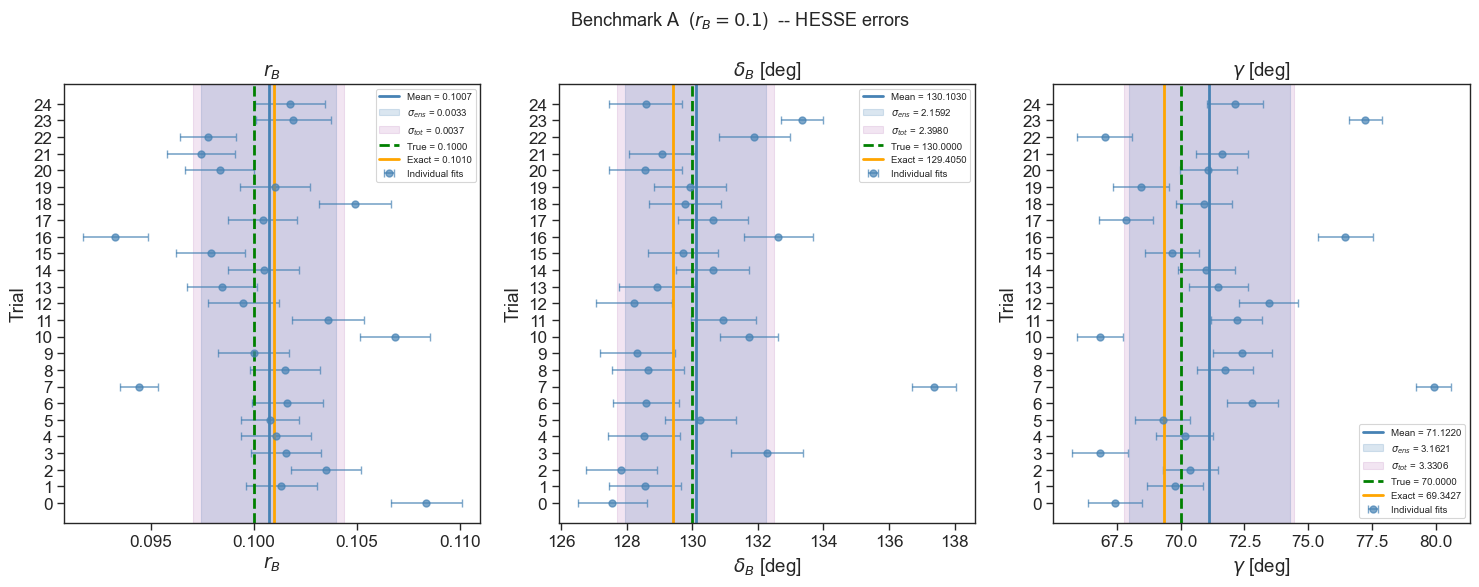

=== Benchmark B - HESSE ===


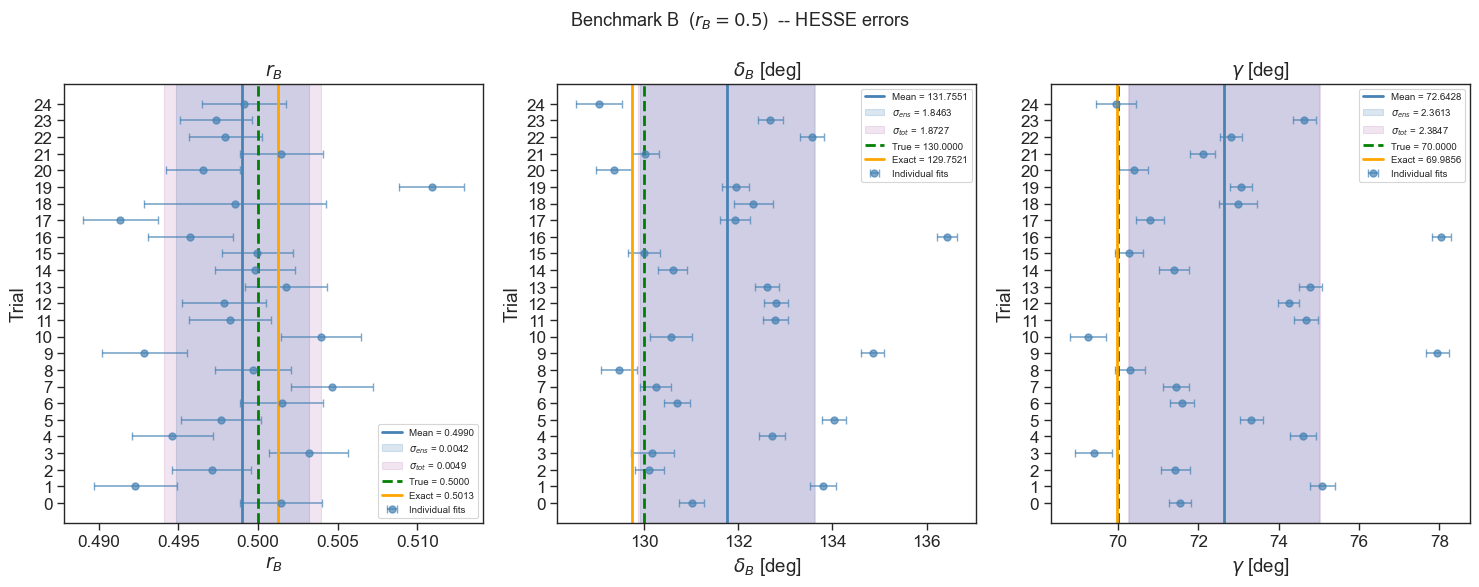

In [75]:
# ============================================================================
# Ensemble fit plots: HESSE and Profile Likelihood (separate functions)
# ============================================================================

def plot_hesse_ensemble(
    flow_ens,
    true_rB, true_deltaB, true_gamma,
    m_exact=None,
    title='', save_path=None,
):
    """Horizontal error-bar plot for HESSE ensemble results."""
    valid = [r for r in flow_ens if r['valid']]

    exact_rB = exact_delta = exact_gamma = None
    if m_exact is not None:
        exact_rB    = m_exact.values['rB']
        exact_delta = m_exact.values['delta']
        exact_gamma = m_exact.values['gamma']

    params = [
        ([r['rB']    for r in valid], [r['err_rB']    for r in valid],
         r'$r_B$',            true_rB,     exact_rB),
        ([r['delta'] for r in valid], [r['err_delta'] for r in valid],
         r'$\delta_B$ [deg]', true_deltaB, exact_delta),
        ([r['gamma'] for r in valid], [r['err_gamma'] for r in valid],
         r'$\gamma$ [deg]',   true_gamma,  exact_gamma),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    fig.suptitle(title, fontsize=13)

    for ax, (vals, errs, label, true_val, exact_val) in zip(axes, params):
        vals  = np.array(vals)
        errs  = np.array(errs)
        y_pos = np.arange(len(vals))

        mean_val    = vals.mean()
        sigma_ens   = vals.std()
        sigma_fit   = errs.mean()
        sigma_total = np.sqrt(sigma_ens**2 + sigma_fit**2)

        ax.errorbar(vals, y_pos, xerr=errs, fmt='o', color='steelblue',
                    capsize=3, markersize=5, alpha=0.7, label='Individual fits')
        ax.axvline(mean_val, color='steelblue', linestyle='-', linewidth=2,
                   label=f'Mean = {mean_val:.4f}')
        ax.axvspan(mean_val - sigma_ens,   mean_val + sigma_ens,
                   alpha=0.20, color='steelblue',
                   label=f'$\\sigma_{{ens}}$ = {sigma_ens:.4f}')
        ax.axvspan(mean_val - sigma_total, mean_val + sigma_total,
                   alpha=0.10, color='purple',
                   label=f'$\\sigma_{{tot}}$ = {sigma_total:.4f}')
        ax.axvline(true_val, color='green', linestyle='--', linewidth=2,
                   label=f'True = {true_val:.4f}')
        if exact_val is not None:
            ax.axvline(exact_val, color='orange', linestyle='-', linewidth=2,
                       label=f'Exact = {exact_val:.4f}')

        ax.set_ylabel('Trial')
        ax.set_xlabel(label)
        ax.set_title(label)
        ax.set_yticks(y_pos)
        ax.legend(fontsize=7, loc='best')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_profile_ensemble(
    flow_prof,
    true_rB, true_deltaB, true_gamma,
    m_exact=None,
    title='', save_path=None,
):
    """Horizontal asymmetric error-bar plot for profile-likelihood ensemble results."""
    valid = [r for r in flow_prof if r['valid']]

    exact_rB = exact_delta = exact_gamma = None
    if m_exact is not None:
        exact_rB    = m_exact.values['rB']
        exact_delta = m_exact.values['delta']
        exact_gamma = m_exact.values['gamma']

    params = [
        ([r['rB']    for r in valid],
         [r['prof_rB']['err_lo']    for r in valid],
         [r['prof_rB']['err_hi']    for r in valid],
         r'$r_B$',            true_rB,     exact_rB),
        ([r['delta'] for r in valid],
         [r['prof_delta']['err_lo'] for r in valid],
         [r['prof_delta']['err_hi'] for r in valid],
         r'$\delta_B$ [deg]', true_deltaB, exact_delta),
        ([r['gamma'] for r in valid],
         [r['prof_gamma']['err_lo'] for r in valid],
         [r['prof_gamma']['err_hi'] for r in valid],
         r'$\gamma$ [deg]',   true_gamma,  exact_gamma),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    fig.suptitle(title, fontsize=13)

    for ax, (vals, err_lo, err_hi, label, true_val, exact_val) in zip(axes, params):
        vals   = np.array(vals)
        err_lo = np.array(err_lo)
        err_hi = np.array(err_hi)
        y_pos  = np.arange(len(vals))

        mean_val    = vals.mean()
        sigma_ens   = vals.std()
        sigma_fit   = np.mean((err_lo + err_hi) / 2)
        sigma_total = np.sqrt(sigma_ens**2 + sigma_fit**2)

        ax.errorbar(vals, y_pos, xerr=[err_lo, err_hi], fmt='o', color='tomato',
                    capsize=3, markersize=5, alpha=0.7, label='Individual fits')
        ax.axvline(mean_val, color='tomato', linestyle='-', linewidth=2,
                   label=f'Mean = {mean_val:.4f}')
        ax.axvspan(mean_val - sigma_ens,   mean_val + sigma_ens,
                   alpha=0.20, color='tomato',
                   label=f'$\\sigma_{{ens}}$ = {sigma_ens:.4f}')
        ax.axvspan(mean_val - sigma_total, mean_val + sigma_total,
                   alpha=0.10, color='purple',
                   label=f'$\\sigma_{{tot}}$ = {sigma_total:.4f}')
        ax.axvline(true_val, color='green', linestyle='--', linewidth=2,
                   label=f'True = {true_val:.4f}')
        if exact_val is not None:
            ax.axvline(exact_val, color='orange', linestyle='-', linewidth=2,
                       label=f'Exact = {exact_val:.4f}')

        ax.set_ylabel('Trial')
        ax.set_xlabel(label)
        ax.set_title(label)
        ax.set_yticks(y_pos)
        ax.legend(fontsize=7, loc='best')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# --- Benchmark A (rB = 0.1) ---
print('=== Benchmark A - HESSE ===')
plot_hesse_ensemble(
    flow_ens_A_avg,
    true_rB=0.1, true_deltaB=130.0, true_gamma=70.0,
    m_exact=m_A_exact,
    title=r'Benchmark A  ($r_B = 0.1$)  -- HESSE errors',
    save_path='ensemble_fit_results_A_hesse.pdf',
)

# print('=== Benchmark A - Profile LH ===')
# plot_profile_ensemble(
#     flow_prof_A,
#     true_rB=0.1, true_deltaB=130.0, true_gamma=70.0,
#     m_exact=m_A_exact,
#     title=r'Benchmark A  ($r_B = 0.1$)  -- Profile-likelihood errors',
#     save_path='ensemble_fit_results_A_profile.pdf',
# )

# --- Benchmark B (rB = 0.5) ---
print('=== Benchmark B - HESSE ===')
plot_hesse_ensemble(
    flow_ens_B_avg,
    true_rB=0.5, true_deltaB=130.0, true_gamma=70.0,
    m_exact=m_B_exact,
    title=r'Benchmark B  ($r_B = 0.5$)  -- HESSE errors',
    save_path='ensemble_fit_results_B_hesse.pdf',
)

# print('=== Benchmark B - Profile LH ===')
# plot_profile_ensemble(
#     flow_prof_B,
#     true_rB=0.5, true_deltaB=130.0, true_gamma=70.0,
#     m_exact=m_B_exact,
#     title=r'Benchmark B  ($r_B = 0.5$)  -- Profile-likelihood errors',
#     save_path='ensemble_fit_results_B_profile.pdf',
# )
